# Adjoint Solver for Spring-Slider Rate-and-State Friction

Extends the existing `springslider.ipynb` forward solver with an adjoint-based gradient computation.

**Setup:** Velocity-strengthening friction (`a > b`), afterslip problem, fixed-step RK4.

**State evolution:** Slip law — matches the existing forward solver exactly.

**Force balance convention:**
$$\tau(V,\psi) + \eta V + k u = \tau_0$$

**Objective function (smoothed-slip misfit):**
$$J = \frac{1}{2}\int_0^T \left(Su - Su_{\rm obs}\right)^2 dt$$

where $S$ is a temporal Gaussian smoothing operator and $u$ is the cumulative slip.

**Adjoint system (backward in time, $u^\dagger = p$, $\psi^\dagger = r$, $p(T)=r(T)=0$):**

From the three adjoint equations (derived via Lagrangian):
$$\delta u:\quad \dot{u}^\dagger = -V^\dagger + \left[S^\top(Su - Su_{\rm obs})\right](t)$$
$$\delta\psi:\quad \dot{\psi}^\dagger = -\tau_\psi\,V^\dagger - G_\psi\,\psi^\dagger$$
$$\delta V:\quad (\tau_V + \eta)\,V^\dagger = -k\,u^\dagger - \psi^\dagger\,G_V$$

**Gradient:**
$$\frac{dJ}{da} = \int_0^T \left[-V^\dagger\,\frac{\partial\tau}{\partial a} - \psi^\dagger\,\frac{\partial G}{\partial a}\right]dt$$

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import scipy.sparse

## Physics: Friction Law and Jacobians

**Regularised RS friction (slip-law form used in original code):**
$$\tau(V,\psi) = N a\,\sinh^{-1}\!\left(\frac{V}{2V_0}e^{\psi/a}\right)$$

**State evolution — slip law:**
$$G(V,\psi) = -\frac{V}{D_c}\left(\frac{\tau}{N} - f_{\rm ss}\right), \quad f_{\rm ss} = f_0 + (a-b)\ln(V/V_0)$$

Partial derivatives are derived analytically.

In [78]:
# ------------------------------------------------------------------
# Friction law
# ------------------------------------------------------------------

def xi_fn(V, psi, M):
    """Argument of arcsinh: xi = V/(2*V0) * exp(psi/a)."""
    return V / (2.0 * M['V0']) * np.exp(psi / M['a'])

def tau_fn(V, psi, M):
    """Frictional strength (MPa)."""
    return M['N'] * M['a'] * np.arcsinh(xi_fn(V, psi, M))

def fss_fn(V, M):
    """Steady-state friction coefficient."""
    return M['f0'] + (M['a'] - M['b']) * np.log(V / M['V0'])

def G_fn(V, psi, M):
    """State evolution dpsi/dt (slip law)."""
    f = tau_fn(V, psi, M) / M['N']
    return -V / M['dc'] * (f - fss_fn(V, M))

# ------------------------------------------------------------------
# Partial derivatives
# ------------------------------------------------------------------

def tau_V_fn(V, psi, M):
    """dtau/dV = N*a / sqrt(1+xi^2) * xi/V."""
    xi = xi_fn(V, psi, M)
    return M['N'] * M['a'] / np.sqrt(1.0 + xi**2) * xi / V

def tau_psi_fn(V, psi, M):
    """dtau/dpsi = N * xi / sqrt(1+xi^2)."""
    xi = xi_fn(V, psi, M)
    return M['N'] * xi / np.sqrt(1.0 + xi**2)

def G_V_fn(V, psi, M):
    """
    dG/dV for slip law.
    G = -(V/dc)*(tau/N - fss), so
    dG/dV = G/V - V*tau_V/(dc*N) + (a-b)/dc
    """
    G  = G_fn(V, psi, M)
    tV = tau_V_fn(V, psi, M)
    return G / V - V * tV / (M['dc'] * M['N']) + (M['a'] - M['b']) / M['dc']

def G_psi_fn(V, psi, M):
    """dG/dpsi = -V * tau_psi / (dc * N)."""
    tP = tau_psi_fn(V, psi, M)
    return -V * tP / (M['dc'] * M['N'])

def dtau_da_fn(V, psi, M):
    """
    Explicit partial dtau/da  (holding V, psi fixed).
    tau = N*a*arcsinh(xi),  xi = V/(2*V0)*exp(psi/a)
    d(tau)/da = N*arcsinh(xi) - N*psi*xi / (a*sqrt(1+xi^2))
    """
    xi = xi_fn(V, psi, M)
    return M['N'] * np.arcsinh(xi) - M['N'] * psi * xi / (M['a'] * np.sqrt(1.0 + xi**2))

def dG_da_fn(V, psi, M):
    """
    Explicit partial dG/da  (holding V, psi fixed).
    G = -(V/dc)*(tau/N - fss),  dfss/da = ln(V/V0)
    dG/da = -(V/dc)*(dtau_da/N - ln(V/V0))
    """
    dtau = dtau_da_fn(V, psi, M)
    return -(V / M['dc']) * (dtau / M['N'] - np.log(V / M['V0']))

print("Physics functions defined.")

Physics functions defined.


## Parameters and Afterslip Initial Conditions

Velocity-strengthening (`a > b`) with a coseismic stress step $\Delta\tau$ at $t=0$.

In [98]:
# ------------------------------------------------------------------
# Force-balance solver:  tau(V,psi) + eta*V + k*u = tau_L  =>  V
# ------------------------------------------------------------------

def solve_V_algebraic(u, psi, M, tau_L):
    """
    Root-find V from  tau(V,psi) + eta*V = tau_L - k*u.
    tau_L is the current loading stress (may vary with time).
    """
    rhs = tau_L - M['k'] * u
    if rhs <= 0.0:
        raise ValueError(f"Force-balance RHS = {rhs:.4g} <= 0; check tau_L and k*u.")
    def res(V):
        return tau_fn(V, psi, M) + M['eta'] * V - rhs
    Vmin = 1e-30
    Vmax = rhs / M['eta']
    return brentq(res, Vmin, Vmax, xtol=1e-20, rtol=1e-10)

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
M = {}
M['f0']  = 0.6
M['V0']  = 1e-6      # m/s reference velocity
M['a']   = 0.010     # direct effect  (a > b → velocity strengthening)
M['b']   = 0.015     # state evolution
M['dc']  = 1e-4      # m critical slip distance
M['N']   = 50.0      # MPa effective normal stress
M['eta'] = 2.7 * 3.5 / 2.0   # MPa·s/m radiation damping
# M['k']   = 2e4       # MPa/m spring stiffness
k_crit = M['N'] * (M['b'] - M['a']) / M['dc']
M['k'] = 1e2

V_bg      = 1e-9     # m/s background / plate sliding rate
M['V_bg'] = V_bg

# ------------------------------------------------------------------
# Steady-state at V_bg
# ------------------------------------------------------------------
fss_bg = fss_fn(V_bg, M)
psi_ss = M['a'] * np.log(2.0 * M['V0'] / V_bg * np.sinh(fss_bg / M['a']))
tau_ss = M['N'] * fss_bg

# ------------------------------------------------------------------
# Initial conditions — V_init is the PRIMARY control parameter.
# tau0 is DERIVED from the force balance at t=0 (u=0):
#   tau(V_init, psi_init) + eta*V_init = tau0
# This ensures the forward solver starts at exactly V_init.
# ------------------------------------------------------------------
V_init   = 1.0e-9      # m/s  post-earthquake initial slip rate
psi_init = psi_ss    # pre-earthquake steady state at V_bg
u_init   = 0.0

M['tau0'] = tau_fn(V_init, psi_init, M) + M['eta'] * V_init
Delta_tau = M['tau0'] - tau_ss   # implied coseismic stress step (diagnostic)

# Characteristic afterslip time  T_c ~ N*a / (k * V_init)
T_c = M['N'] * M['a'] / (M['k'] * V_init)

print(f"a={M['a']}, b={M['b']}  →  velocity {'strengthening' if M['a']>M['b'] else 'weakening'}")
print(f"V_bg   = {V_bg:.2e} m/s,   V_init = {V_init:.2e} m/s  (ratio {V_init/V_bg:.1f}×)")
print(f"psi_ss = {psi_ss:.4f}")
print(f"tau_ss = {tau_ss:.4f} MPa")
print(f"tau0   = {M['tau0']:.4f} MPa  (Delta_tau = {Delta_tau:.4f} MPa)")
print(f"T_c    = {T_c:.3e} s  ({T_c/86400:.1f} days)")
print(f"k      = {M['k']:.2e} MPa/m,   k_crit = {k_crit:.2e} MPa/m  (k/k_crit = {M['k']/k_crit:.2f})")

a=0.01, b=0.015  →  velocity weakening
V_bg   = 1.00e-09 m/s,   V_init = 1.00e-09 m/s  (ratio 1.0×)
psi_ss = 0.7036
tau_ss = 31.7269 MPa
tau0   = 31.7269 MPa  (Delta_tau = 0.0000 MPa)
T_c    = 5.000e+06 s  (57.9 days)
k      = 1.00e+02 MPa/m,   k_crit = 2.50e+03 MPa/m  (k/k_crit = 0.04)


## Adaptive Forward Solver

Uses a 3-stage embedded RK method (2nd/3rd-order pair) for automatic step-size control,
matching the MATLAB reference implementation.

**Method:** Three stages per trial step; accept if $\|[\Delta u,\,\Delta\psi]\|_2 < \text{tol}$;
adjust $\Delta t \leftarrow \sigma\,\Delta t\,(\text{tol}/e)^{1/3}$ where $\sigma=0.9$ is a safety factor.


In [115]:
def forward_solve_adaptive(M, T, u0, psi0, V_init=None,
                           tol=1e-4, dt0=1.0, dtmax=1e5, safety=0.9):
    """
    Adaptive-step forward solve using a 3-stage embedded RK method
    (2nd/3rd-order error-control pair, matching the MATLAB reference).

    Loading: tau_L(t) = tau0 + k*V_bg*t
    ODE:     du/dt = V,   dpsi/dt = G(V,psi)
    Algebraic: tau(V,psi) + eta*V + k*u = tau_L(t)  =>  V
    """
    tau_L_fn = lambda t: M['tau0'] + M['k'] * M['V_bg'] * t

    V0 = solve_V_algebraic(u0, psi0, M, tau_L_fn(0.0))
    if V_init is not None:
        rel_err = abs(V0 - V_init) / V_init
        assert rel_err < 1e-6, (
            f"Init mismatch: V(0)={V0:.6e}, V_init={V_init:.6e} (rel={rel_err:.2e})"
        )

    def _rhs(u_v, psi_v, t_v):
        V = solve_V_algebraic(u_v, psi_v, M, tau_L_fn(t_v))
        return V, G_fn(V, psi_v, M)

    def _jac(V, psi):
        return (tau_V_fn(V,psi,M), tau_psi_fn(V,psi,M),
                G_V_fn(V,psi,M),   G_psi_fn(V,psi,M),
                dtau_da_fn(V,psi,M), dG_da_fn(V,psi,M))

    # Initialise storage
    t_arr = [0.0]; u_arr = [u0]; psi_arr = [psi0]
    V_arr = [V0];  tauL_arr = [tau_L_fn(0.0)]
    j = _jac(V0, psi0)
    tV_arr=[j[0]]; tP_arr=[j[1]]; GV_arr=[j[2]]
    GP_arr=[j[3]]; da_arr=[j[4]]; dGa_arr=[j[5]]

    t = 0.0; u = u0; psi = psi0; dt = dt0
    V1, G1 = V0, G_fn(V0, psi0, M)   # stage-1 values at t=0

    while t < T:
        if t + dt > T:
            dt = T - t

        # --- three-stage embedded RK ---
        V2, G2 = _rhs(u + 0.5*dt*V1,         psi + 0.5*dt*G1,         t + 0.5*dt)
        V3, G3 = _rhs(u + dt*(-V1 + 2.0*V2), psi + dt*(-G1 + 2.0*G2), t +     dt)

        u2   = u   + dt/2.0*(V1 + V3)            # 2nd-order update
        psi2 = psi + dt/2.0*(G1 + G3)
        u3   = u   + dt/6.0*(V1 + 4.0*V2 + V3)  # 3rd-order update
        psi3 = psi + dt/6.0*(G1 + 4.0*G2 + G3)

        er = np.sqrt((u2 - u3)**2 + (psi2 - psi3)**2)

        if er < tol:
            t += dt;  u = u3;  psi = psi3
            tL    = tau_L_fn(t)
            V_new = solve_V_algebraic(u, psi, M, tL)

            t_arr.append(t);     u_arr.append(u);    psi_arr.append(psi)
            V_arr.append(V_new); tauL_arr.append(tL)
            j = _jac(V_new, psi)
            tV_arr.append(j[0]); tP_arr.append(j[1]); GV_arr.append(j[2])
            GP_arr.append(j[3]); da_arr.append(j[4]); dGa_arr.append(j[5])

            V1 = V_new;  G1 = G_fn(V_new, psi, M)  # stage-1 for next step

        # Step-size control  (q=2 → exponent 1/3)
        dt = safety * dt * (tol / er)**(1.0/3.0) if er > 0.0 else dtmax
        dt = min(dt, dtmax)

    return dict(
        t       = np.array(t_arr),
        u       = np.array(u_arr),
        psi     = np.array(psi_arr),
        V       = np.array(V_arr),
        tau_L   = np.array(tauL_arr),
        tau_V   = np.array(tV_arr),
        tau_psi = np.array(tP_arr),
        G_V     = np.array(GV_arr),
        G_psi   = np.array(GP_arr),
        dtau_da = np.array(da_arr),
        dG_da   = np.array(dGa_arr),
    )

# --- Run adaptive forward solve ---
T = 5e8    # s
print(f"Running adaptive forward solve: T={T:.1e} s ...")
fwd = forward_solve_adaptive(M, T, u_init, psi_init, V_init=V_init)
print(f"Done.  Steps={len(fwd['t'])-1},  V(0)={fwd['V'][0]:.6e},  V(T)={fwd['V'][-1]:.3e} m/s")
print(f"tau_L: {fwd['tau_L'][0]:.4f} → {fwd['tau_L'][-1]:.4f} MPa")


Running adaptive forward solve: T=5.0e+08 s ...
Done.  Steps=8249,  V(0)=1.000000e-09,  V(T)=2.550e-12 m/s
tau_L: 31.7269 → 81.7269 MPa


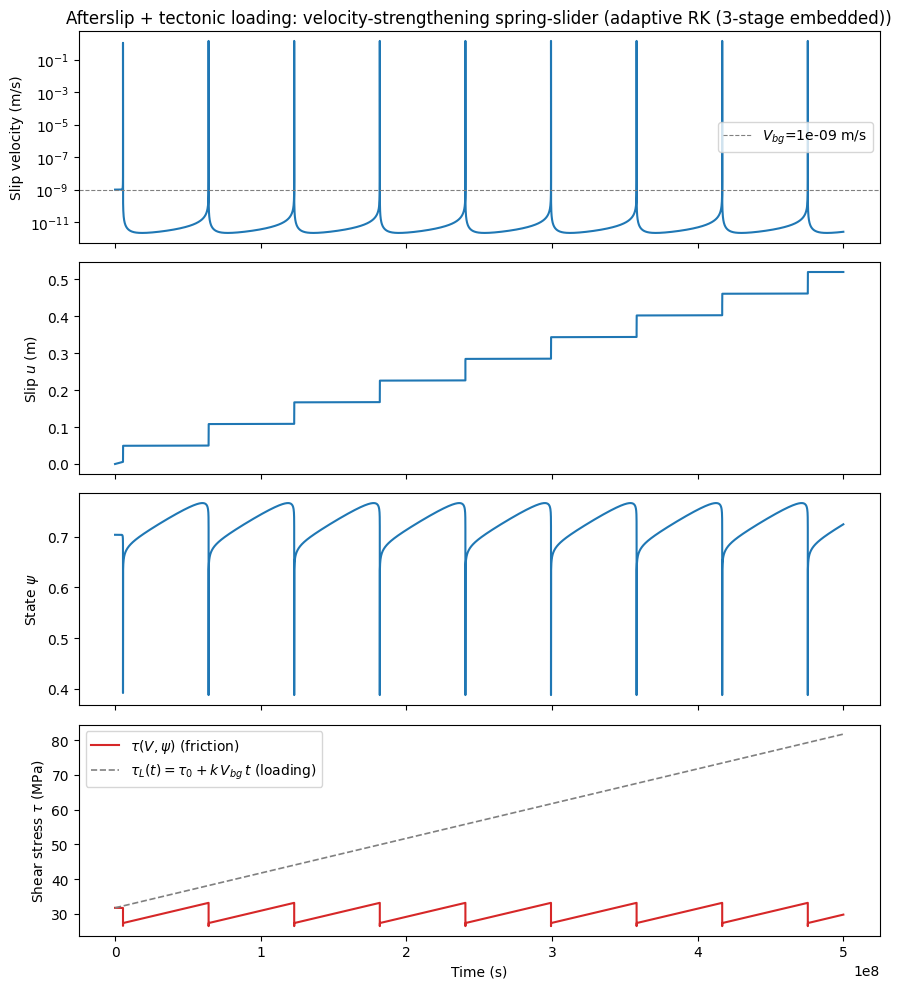

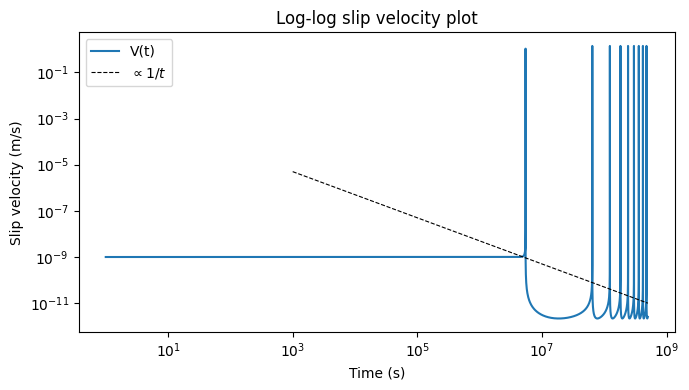

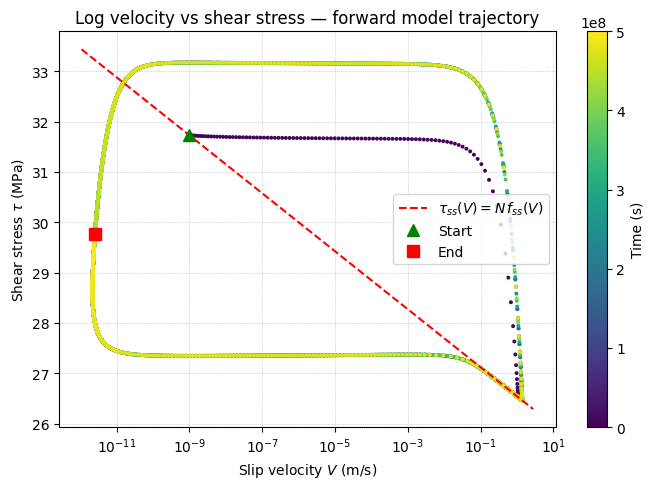

tau range: 26.4627 – 33.1700 MPa
V   range: 2.166e-12 – 1.396e+00 m/s


In [116]:
# ------------------------------------------------------------------
# Plot 1: Forward solution
# ------------------------------------------------------------------
tau_fwd = np.array([tau_fn(v, p, M) for v, p in zip(fwd['V'], fwd['psi'])])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(fwd['t'], fwd['V'])
axes[0].axhline(V_bg, color='gray', ls='--', lw=0.8, label=f'$V_{{bg}}$={V_bg:.0e} m/s')
axes[0].set_ylabel('Slip velocity (m/s)')
axes[0].set_yscale('log')
axes[0].set_title('Afterslip + tectonic loading: velocity-strengthening spring-slider (adaptive RK (3-stage embedded))')
axes[0].legend()

axes[1].plot(fwd['t'], fwd['u'])
axes[1].set_ylabel('Slip $u$ (m)')

axes[2].plot(fwd['t'], fwd['psi'])
axes[2].set_ylabel('State $\\psi$')

axes[3].plot(fwd['t'], tau_fwd, color='C3', label=r'$\tau(V,\psi)$ (friction)')
axes[3].plot(fwd['t'], fwd['tau_L'], color='gray', ls='--', lw=1.2,
             label=r'$\tau_L(t) = \tau_0 + k\,V_{bg}\,t$ (loading)')
axes[3].set_ylabel('Shear stress $\\tau$ (MPa)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()

# Verify Omori-like 1/t decay by log-log plot
fig2, ax2 = plt.subplots(figsize=(7, 4))
t_plot = fwd['t'][1:]
V_plot = fwd['V'][1:]
ax2.loglog(t_plot, V_plot, label='V(t)')
t_ref = np.array([1e3, T])
ax2.loglog(t_ref, V_init * T_c / t_ref, 'k--', lw=0.8, label=r'$\propto 1/t$')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Slip velocity (m/s)')
ax2.set_title('Log-log slip velocity plot')
ax2.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 1c: Log velocity vs shear stress (phase portrait)
# ------------------------------------------------------------------
V_min = fwd['V'].min() * 0.5
V_max = fwd['V'].max() * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
tau_ss_line = M['N'] * fss_fn(V_ss, M)

fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(fwd['V'], tau_fwd, c=fwd['t'], cmap='viridis',
                 s=8, lw=0, zorder=3)
ax3.plot(V_ss, tau_ss_line, 'r--', lw=1.5, zorder=4,
         label=r'$\tau_{ss}(V) = N\,f_{ss}(V)$')
ax3.set_xscale('log')
ax3.set_ylabel('Shear stress $\\tau$ (MPa)')
ax3.set_xlabel('Slip velocity $V$ (m/s)')
ax3.set_title('Log velocity vs shear stress — forward model trajectory')
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label('Time (s)')
ax3.plot(fwd['V'][0],  tau_fwd[0],  'g^', ms=8, zorder=5, label='Start')
ax3.plot(fwd['V'][-1], tau_fwd[-1], 'rs', ms=8, zorder=5, label='End')
ax3.legend()
ax3.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"tau range: {tau_fwd.min():.4f} – {tau_fwd.max():.4f} MPa")
print(f"V   range: {fwd['V'].min():.3e} – {fwd['V'].max():.3e} m/s")

## Adaptive Adjoint Solver

The adjoint is formulated as a **forward** integration in reversed time $\tau = T - t$.
Substituting $\tau = T-t$ into the backward adjoint equations gives a standard IVP
from $\tau=0$ (at $t=T$) to $\tau=T$ (at $t=0$), with zero initial conditions.

**Adjoint ODEs in $\tau$ (no smoothing, $S = I$):**
$$\frac{dp}{d\tau} = V^\dagger(\tau) - \bigl[u(T-\tau) - u_{\rm obs}(T-\tau)\bigr]$$
$$\frac{dr}{d\tau} = \tau_\psi(T-\tau)\,V^\dagger + G_\psi(T-\tau)\,r$$
$$V^\dagger(\tau) = \frac{-k\,p - G_V(T-\tau)\,r}{\tau_V(T-\tau) + \eta}$$

**ICs:** $p(0) = r(0) = 0$

Forward-solution Jacobians and the misfit $(u - u_{\rm obs})$ are evaluated at $t = T-\tau$
by linear interpolation from the adaptive forward-solve grid.

The same 3-stage embedded RK step-size controller is used for both forward and adjoint solves.


In [110]:
def adjoint_solve_adaptive(fwd, t_obs, u_obs, M,
                           tol=1e-4, dt0=1.0, dtmax=1e5, safety=0.9):
    """
    Adaptive adjoint solve for J = 0.5 * int_0^T (u - u_obs)^2 dt.

    Integrates the time-reversed adjoint equations *forward* in
    tau = T - t, from tau=0 (t=T) to tau=T (t=0), with zero ICs.

    Adjoint ODEs in tau:
        dp/dtau =  V†(tau) - (u(T-tau) - u_obs(T-tau))
        dr/dtau =  tau_psi(T-tau)*V†  +  G_psi(T-tau)*r
        V†(tau) = [-k*p - G_V(T-tau)*r] / (tau_V(T-tau) + eta)

    All forward-solution quantities are pre-stacked into a single array
    so each RHS evaluation does ONE binary search instead of six,
    giving ~5-6x speedup on the inner loop.
    """
    T   = fwd['t'][-1]
    k   = M['k']
    eta = M['eta']

    _t = fwd['t']
    n  = len(_t)

    # Pre-interpolate u_obs onto the forward time grid ONCE, compute misfit there.
    u_obs_fwd  = np.interp(_t, t_obs, u_obs)
    misfit_fwd = fwd['u'] - u_obs_fwd          # shape (n,)

    # Stack [tau_V, tau_psi, G_V, G_psi, misfit] → (n, 5)
    # One searchsorted per RHS call replaces six np.interp calls.
    _stack = np.column_stack([
        fwd['tau_V'], fwd['tau_psi'],
        fwd['G_V'],   fwd['G_psi'],
        misfit_fwd
    ])
    _nmax = n - 2   # max valid lower-bound index for interpolation

    def _interp(t_v):
        i    = min(np.searchsorted(_t, t_v, side='right') - 1, _nmax)
        i    = max(i, 0)
        dt_i = _t[i + 1] - _t[i]
        frac = (t_v - _t[i]) / dt_i if dt_i > 0.0 else 0.0
        return _stack[i] + frac * (_stack[i + 1] - _stack[i])

    def _rhs(tau_v, p_v, r_v):
        tV, tP, GV, GP, mf = _interp(T - tau_v)
        Vdt = (-k * p_v - GV * r_v) / (tV + eta)
        dp  = Vdt - mf
        dr  = tP * Vdt + GP * r_v
        return dp, dr, Vdt

    # Initial conditions at tau=0 (t=T)
    tau = 0.0;  p = 0.0;  r = 0.0;  dt = dt0
    tau_arr = [tau];  p_arr = [p];  r_arr = [r]
    dp1, dr1, Vdt1 = _rhs(tau, p, r)
    Vdt_arr = [Vdt1]

    while tau < T:
        if tau + dt > T:
            dt = T - tau

        # --- three-stage embedded RK ---
        dp2, dr2, _ = _rhs(tau + 0.5*dt, p + 0.5*dt*dp1,         r + 0.5*dt*dr1)
        dp3, dr3, _ = _rhs(tau +     dt, p + dt*(-dp1 + 2.0*dp2), r + dt*(-dr1 + 2.0*dr2))

        p2 = p + dt/2.0*(dp1 + dp3)            # 2nd-order
        r2 = r + dt/2.0*(dr1 + dr3)
        p3 = p + dt/6.0*(dp1 + 4.0*dp2 + dp3)  # 3rd-order
        r3 = r + dt/6.0*(dr1 + 4.0*dr2 + dr3)

        er = np.sqrt((p2 - p3)**2 + (r2 - r3)**2)

        if er < tol:
            tau += dt;  p = p3;  r = r3
            tau_arr.append(tau);  p_arr.append(p);  r_arr.append(r)
            dp1, dr1, Vdt1 = _rhs(tau, p, r)
            Vdt_arr.append(Vdt1)

        # Step-size control  (q=2 → exponent 1/3)
        dt = safety * dt * (tol / er)**(1.0/3.0) if er > 0.0 else dtmax
        dt = min(dt, dtmax)

    # Reverse tau-arrays back to t-coordinates (t = T - tau)
    tau_out = np.array(tau_arr)
    t_out   = T - tau_out[::-1]          # t: 0 → T
    p_out   = np.array(p_arr)[::-1]
    r_out   = np.array(r_arr)[::-1]
    Vdt_out = np.array(Vdt_arr)[::-1]

    return dict(t=t_out, p=p_out, r=r_out, Vdt=Vdt_out)

print("Adaptive adjoint solver defined.")


## Objective Function and Gradient

In [113]:
def compute_J(fwd, t_obs, u_obs):
    """J = 0.5 * int_0^T (u - u_obs)^2 dt  (trapezoidal, no smoothing)."""
    u_obs_at_fwd = np.interp(fwd['t'], t_obs, u_obs)
    return 0.5 * np.trapz((fwd['u'] - u_obs_at_fwd)**2, fwd['t'])

def compute_grad_a(fwd, adj, M):
    """
    dJ/da = int_0^T [ -V† dtau/da  -  ψ† dG/da ] dt

    fwd and adj may have different time grids; dtau_da and dG_da
    are interpolated from fwd onto adj's time points.
    """
    dtau_da_adj = np.interp(adj['t'], fwd['t'], fwd['dtau_da'])
    dG_da_adj   = np.interp(adj['t'], fwd['t'], fwd['dG_da'])
    integrand   = -adj['Vdt'] * dtau_da_adj - adj['r'] * dG_da_adj
    return np.trapz(integrand, adj['t'])

# ------------------------------------------------------------------
# Generate synthetic observations at TRUE parameters
# ------------------------------------------------------------------
M_true = dict(M)
print("Generating synthetic u_obs with true a =", M_true['a'])
fwd_true  = forward_solve_adaptive(M_true, T, u_init, psi_init, V_init=V_init)
t_obs_arr = fwd_true['t']
u_obs     = fwd_true['u'].copy()
print(f"u_obs: u(0)={u_obs[0]:.4e} m,  u(T)={u_obs[-1]:.4e} m  ({len(t_obs_arr)} pts)")

J_true = compute_J(fwd_true, t_obs_arr, u_obs)
print(f"J at true parameters: {J_true:.2e}  (should be ~0)")


Generating synthetic u_obs with true a = 0.01
u_obs: u(0)=0.0000e+00 m,  u(T)=1.0818e-01 m  (1681 pts)
J at true parameters: 0.00e+00  (should be ~0)


In [114]:
# ------------------------------------------------------------------
# Run at perturbed a, then solve adjoint and compute gradient
# ------------------------------------------------------------------
M_test      = dict(M_true)
M_test['a'] = M_true['a'] * 1.10   # 10% perturbation

print(f"Perturbed a = {M_test['a']:.5f}  (true a = {M_true['a']:.5f})")
fwd_test = forward_solve_adaptive(M_test, T, u_init, psi_init)
J_test   = compute_J(fwd_test, t_obs_arr, u_obs)
print(f"J at perturbed a: {J_test:.6e}  ({len(fwd_test['t'])-1} fwd steps)")

adj_test = adjoint_solve_adaptive(fwd_test, t_obs_arr, u_obs, M_test)
grad_adj = compute_grad_a(fwd_test, adj_test, M_test)
print(f"Adjoint gradient dJ/da = {grad_adj:.6e}  ({len(adj_test['t'])-1} adj steps)")


Perturbed a = 0.01100  (true a = 0.01000)
J at perturbed a: 2.504913e+04  (1951 fwd steps)


KeyboardInterrupt: 

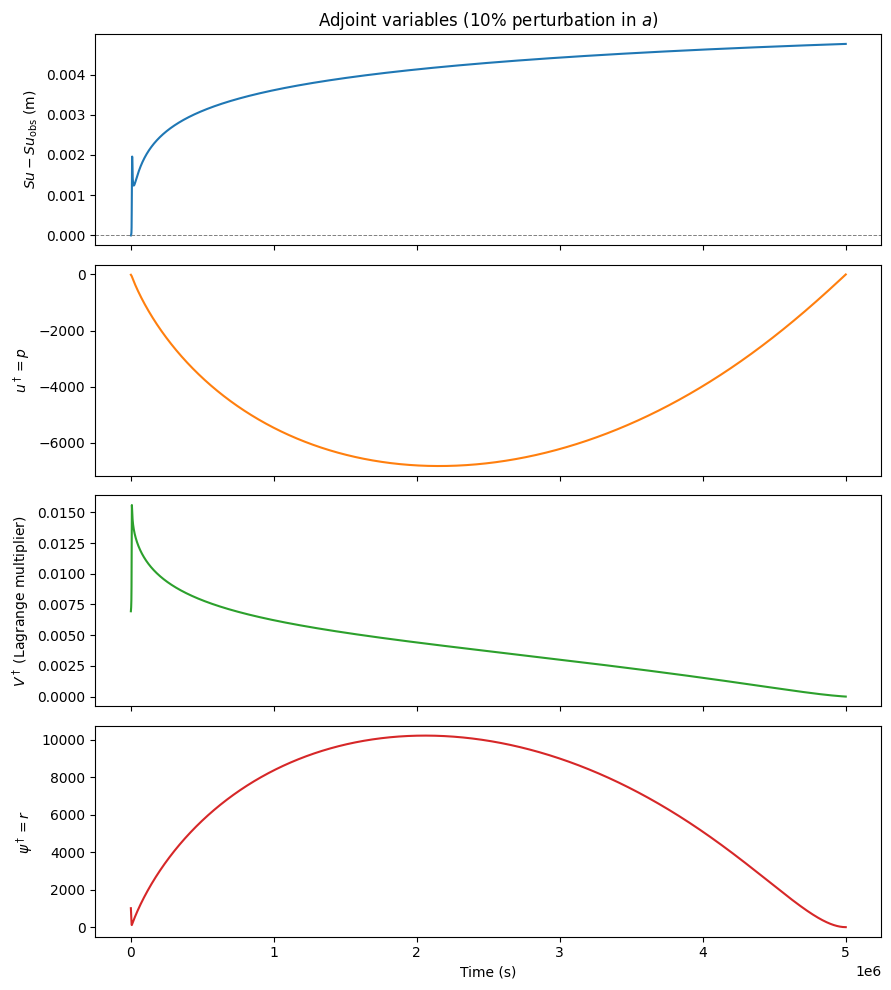

p(T) = 0.00e+00  (should be 0)
r(T) = 0.00e+00  (should be 0)


In [62]:
# ------------------------------------------------------------------
# Plot 2: Adjoint variables + slip misfit
# ------------------------------------------------------------------
misfit_fwd = fwd_test['u'] - np.interp(fwd_test['t'], t_obs_arr, u_obs)

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=False)

axes[0].plot(fwd_test['t'], misfit_fwd, color='C0')
axes[0].set_ylabel(r'$u - u_{\rm obs}$ (m)')
axes[0].set_title('Adjoint variables (10% perturbation in $a$)')
axes[0].axhline(0, color='gray', lw=0.7, ls='--')

axes[1].plot(adj_test['t'], adj_test['p'], color='C1')
axes[1].set_ylabel(r'$u^\dagger = p$')

axes[2].plot(adj_test['t'], adj_test['Vdt'], color='C2')
axes[2].set_ylabel(r'$V^\dagger$ (Lagrange multiplier)')

axes[3].plot(adj_test['t'], adj_test['r'], color='C3')
axes[3].set_ylabel(r'$\psi^\dagger = r$')
axes[3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print(f"p(T) = {adj_test['p'][-1]:.2e}  (should be ~0)")
print(f"r(T) = {adj_test['r'][-1]:.2e}  (should be ~0)")


## Simple Gradient Descent: Recover True $a$

Start at $a = 1.1\,a_{\rm true}$, take gradient steps $a \leftarrow a - \alpha\,dJ/da$.

The step size is kept fixed (chosen so early steps don't overshoot).

In [ ]:
a_true_val = M_true['a']
a_curr     = a_true_val * 1.23

a_min = 1e-4
a_max = 10 * a_true_val

alpha_init = abs(a_curr) / abs(grad_adj) * 0.01

n_iter    = 15
J_hist    = []
a_hist    = [a_curr]
grad_hist = []
u_hist    = []
t_hist    = []   # time grids for each iteration (adaptive → variable length)

a_prev    = None
grad_prev = None

for it in range(n_iter):
    Mc = dict(M_true)
    Mc['a'] = a_curr

    fwd_it  = forward_solve_adaptive(Mc, T, u_init, psi_init)
    J_it    = compute_J(fwd_it, t_obs_arr, u_obs)
    adj_it  = adjoint_solve_adaptive(fwd_it, t_obs_arr, u_obs, Mc)
    grad_it = compute_grad_a(fwd_it, adj_it, Mc)

    J_hist.append(J_it)
    grad_hist.append(grad_it)
    u_hist.append(fwd_it['u'].copy())
    t_hist.append(fwd_it['t'].copy())

    # Barzilai-Borwein step size, capped at 30% of current |a|
    if a_prev is None or abs(grad_it - grad_prev) < 1e-30:
        alpha = alpha_init
    else:
        alpha_bb  = abs((a_curr - a_prev) / (grad_it - grad_prev))
        alpha_cap = 0.30 * abs(a_curr) / (abs(grad_it) + 1e-30)
        alpha = min(alpha_bb, alpha_cap)

    a_prev    = a_curr
    grad_prev = grad_it

    # Backtracking line search
    found = False
    a_try = a_curr
    for bt in range(12):
        a_try = float(np.clip(a_curr - alpha * grad_it, a_min, a_max))
        try:
            Mc_try = dict(M_true)
            Mc_try['a'] = a_try
            forward_solve_adaptive(Mc_try, T, u_init, psi_init)
            found = True
            break
        except (ValueError, RuntimeError):
            alpha *= 0.5

    bt_note = (f"  [backtracked {bt}x, α→{alpha:.3e}]" if (found and bt > 0)
               else ("  [backtracking exhausted]" if not found else ""))

    if not found:
        a_try = a_curr

    a_curr = a_try
    a_hist.append(a_curr)

    print(f"iter {it+1:3d}: J={J_it:.4e},  a={a_curr:.6f},  "
          f"a_err={abs(a_curr-a_true_val)/a_true_val*100:.3f}%,  "
          f"α={alpha:.3e},  dJ/da={grad_it:.4e}{bt_note}")
    if abs(grad_it) < 1e-8: break
    if not found: break


iter   1: J = 2.1393e+02,  a = 0.018054,  a_err = 20.362%,  α = 3.326e-11,  dJ/da = 1.1898e+07
iter   2: J = 1.6925e+02,  a = 0.014605,  a_err = 2.636%,  α = 3.232e-10,  dJ/da = 1.0673e+07
iter   3: J = 3.1208e+00,  a = 0.015051,  a_err = 0.343%,  α = 2.813e-10,  dJ/da = -1.5881e+06
iter   4: J = 5.1972e-02,  a = 0.015001,  a_err = 0.006%,  α = 2.496e-10,  dJ/da = 2.0207e+05
iter   5: J = 1.7891e-05,  a = 0.015000,  a_err = 0.000%,  α = 2.543e-10,  dJ/da = 3.7549e+03
iter   6: J = 1.0076e-10,  a = 0.015000,  a_err = 0.000%,  α = 2.537e-10,  dJ/da = -8.9114e+00
iter   7: J = 1.9579e-19,  a = 0.015000,  a_err = 0.000%,  α = 2.537e-10,  dJ/da = 3.9283e-04
iter   8: J = 3.1134e-28,  a = 0.015000,  a_err = 0.000%,  α = 2.537e-10,  dJ/da = 1.3855e-08
iter   9: J = 1.3507e-28,  a = 0.015000,  a_err = 0.000%,  α = 4.240e-10,  dJ/da = 5.6726e-09
iter  10: J = 0.0000e+00,  a = 0.015000,  a_err = 0.000%,  α = 3.058e-10,  dJ/da = 0.0000e+00
iter  11: J = 0.0000e+00,  a = 0.015000,  a_err = 0.000%,

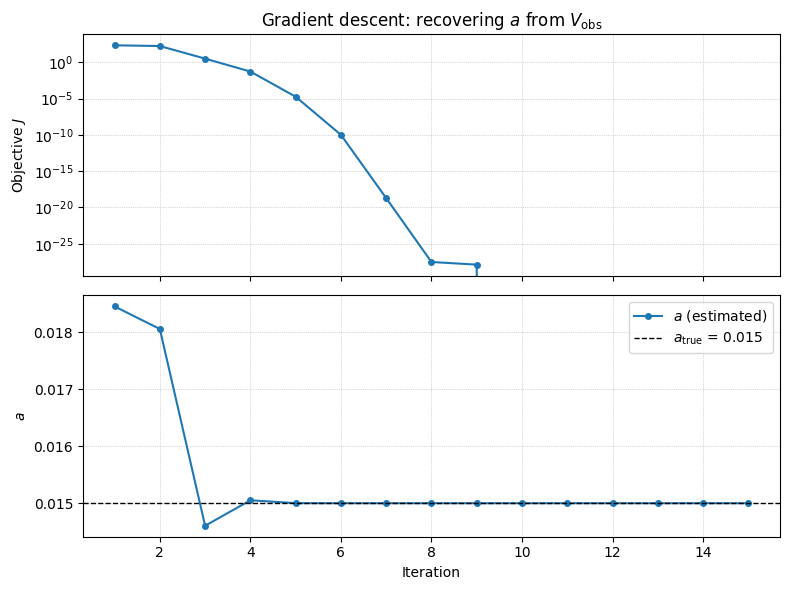


Final a = 0.015000  (true a = 0.015000,  error = 0.0000%)


In [65]:
# ------------------------------------------------------------------
# Plot 4: Gradient descent convergence
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

iters = np.arange(1, n_iter + 1)

axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('Objective $J$')
axes[0].set_title('Gradient descent: recovering $a$ from $V_{\\rm obs}$')
axes[0].grid(True, ls=':', lw=0.5)

axes[1].plot(iters, a_hist[:-1], 'o-', ms=4, label='$a$ (estimated)')
axes[1].axhline(a_true_val, color='k', ls='--', lw=1.0, label=f'$a_{{\\rm true}}$ = {a_true_val}')
axes[1].set_ylabel('$a$')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal a = {a_hist[-1]:.6f}  (true a = {a_true_val:.6f},  "
      f"error = {abs(a_hist[-1]-a_true_val)/a_true_val*100:.4f}%)")

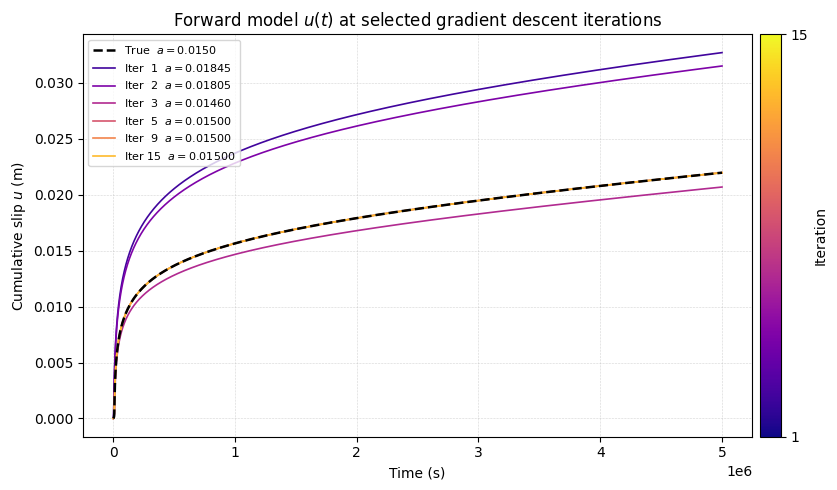

In [66]:
# ------------------------------------------------------------------
# Plot 5: Forward model u(t) — custom a value OR gradient descent overlay
# ------------------------------------------------------------------
custom_a      = None          # e.g. 0.012; set None for GD overlay
iters_to_plot = None          # e.g. [1, 3, 7, 15]; None = auto-select

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t_obs_arr, u_obs, 'k--', lw=1.8,
        label=f'True  $a={a_true_val:.4f}$', zorder=5)

if custom_a is not None:
    print(f"Running forward solve for custom a = {custom_a} ...")
    Mc = dict(M_true); Mc['a'] = custom_a
    fwd_custom = forward_solve_adaptive(Mc, T, u_init, psi_init)
    J_custom   = compute_J(fwd_custom, t_obs_arr, u_obs)
    ax.plot(fwd_custom['t'], fwd_custom['u'], color='C1', lw=1.8, ls='--',
            label=f'Custom  $a={custom_a:.5f}$  ($J={J_custom:.2e}$)')
    ax.set_title(f'Forward model $u(t)$: custom $a={custom_a}$ vs true $a={a_true_val}$')
    print(f"J(custom a) = {J_custom:.4e}")

else:
    if iters_to_plot is None:
        idx_auto  = np.unique(np.round(
            np.geomspace(1, n_iter, 6)).astype(int).clip(1, n_iter)) - 1
        iters_idx = sorted(set(idx_auto.tolist() + [n_iter - 1]))
    else:
        iters_idx = [i - 1 for i in iters_to_plot]

    cmap_gd = plt.cm.plasma
    colors  = cmap_gd(np.linspace(0.1, 0.85, len(iters_idx)))

    for color, idx in zip(colors, iters_idx):
        ax.plot(t_hist[idx], u_hist[idx], color=color, lw=1.2,
                label=f'Iter {idx+1:2d}  $a={a_hist[idx]:.5f}$')

    ax.set_title('Forward model $u(t)$ at selected gradient descent iterations')

    sm = plt.cm.ScalarMappable(cmap=cmap_gd,
         norm=plt.Normalize(vmin=1, vmax=n_iter))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Iteration')
    cbar.set_ticks([iters_idx[0] + 1, iters_idx[-1] + 1])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative slip $u$ (m)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, ls=':', lw=0.4, which='both')
plt.tight_layout()
plt.show()


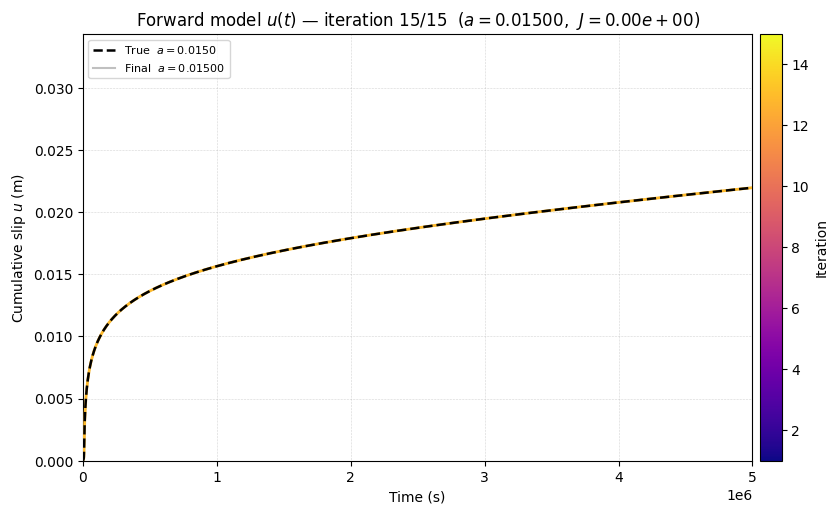

In [67]:
# ------------------------------------------------------------------
# Plot 5 (animated): cycle through gradient descent iterations.
# ------------------------------------------------------------------
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig_anim, ax_anim = plt.subplots(figsize=(9, 5))

ax_anim.plot(t_obs_arr, u_obs, 'k--', lw=1.8,
             label=f'True  $a={a_true_val:.4f}$', zorder=5)

line_final, = ax_anim.plot(t_hist[-1], u_hist[-1], color='silver', lw=1.5,
                            ls='-', label=f'Final  $a={a_hist[n_iter]:.5f}$', zorder=2)

cmap_anim = plt.cm.plasma
line_curr, = ax_anim.plot([], [], lw=2.0, zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap_anim,
     norm=plt.Normalize(vmin=1, vmax=n_iter))
sm.set_array([])
cbar_anim = fig_anim.colorbar(sm, ax=ax_anim, pad=0.01)
cbar_anim.set_label('Iteration')

ax_anim.set_xlabel('Time (s)')
ax_anim.set_ylabel('Cumulative slip $u$ (m)')
ax_anim.grid(True, ls=':', lw=0.4, which='both')

all_u = np.concatenate(u_hist + [u_obs])
ax_anim.set_ylim(all_u.min() * 0.95, all_u.max() * 1.05)
ax_anim.set_xlim(t_obs_arr[0], t_obs_arr[-1])
ax_anim.legend(fontsize=8, loc='upper left')
title_obj = ax_anim.set_title('')

def _init():
    line_curr.set_data([], [])
    return line_curr, title_obj

def _update(frame):
    idx   = frame
    color = cmap_anim((idx) / max(n_iter - 1, 1) * 0.75 + 0.1)
    line_curr.set_data(t_hist[idx], u_hist[idx])
    line_curr.set_color(color)
    title_obj.set_text(
        f'Forward model $u(t)$ — iteration {idx+1}/{n_iter}  '
        f'($a={a_hist[idx]:.5f}$,  $J={J_hist[idx]:.2e}$)'
    )
    return line_curr, title_obj

anim = FuncAnimation(
    fig_anim, _update,
    frames=n_iter,
    init_func=_init,
    interval=600,
    blit=True,
    repeat=True,
)

plt.tight_layout()
HTML(anim.to_jshtml())
